In [1]:

from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.messages import RemoveMessage

c:\Users\Admin\Desktop\work\Agentic_AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [4]:
model=ChatGroq(model="llama-3.3-70b-versatile")

In [7]:
def chat(state:MessagesState):
    response= model.invoke(state["messages"])
    return {"messages":[response]}

def delete_old_messages(state:MessagesState):
    msgs= state["messages"]

    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages":[RemoveMessage(id=m.id) for m in to_remove]}
    
    return{}

In [8]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [9]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [10]:
graph = builder.compile(checkpointer=InMemorySaver())

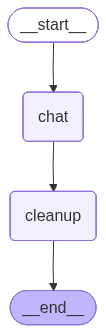

In [11]:
graph

In [12]:
config = {"configurable": {"thread_id": "t1"}}

In [13]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Reeya"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='8e60e1ff-1a05-4a8d-8275-00e48f4c102b'),
  AIMessage(content='LangChain is an open-source framework designed to simplify the development and deployment of large language models (LLMs) like LangGraph. It provides a set of tools, libraries, and APIs that enable developers to build, train, and integrate LLMs into various applications.\n\n**Key Features of LangChain:**\n\n1. **Modular Architecture**: LangChain has a modular design, allowing developers to swap out different components, such as models, tokenizers, and optimizers, to create customized LLM pipelines.\n2. **Model Agnostic**: LangChain supports a wide range of LLMs, including LangGraph, Transformers, and other popular models, making it easy to experiment with different architectures and models.\n3. **Pre-built Components**: LangChain provides pre-built components for common tasks, such as text classification, question answering

In [14]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
